In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [13]:
from sklearn.compose import ColumnTransformer

In [14]:
df = pd.read_csv('Obesity.csv')

In [29]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,Obeso_bin
0,Female,21.0,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,0
1,Female,21.0,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,0
2,Male,23.0,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,0
3,Male,27.0,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,0
4,Male,22.0,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,0


In [15]:
# =====================================================
# FEATURE ENGINEERING
# AJUSTANDO TIPOS PRIMITIVOS
# =====================================================

cols_to_round = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for col in cols_to_round:
    df[col] = df[col].round().astype(int)

In [16]:
obese_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
df['Obeso_bin'] = df['Obesity'].apply(lambda x: 1 if x in obese_classes else 0)

In [17]:
X = df.drop(['Obesity', 'Obeso_bin'], axis=1)
y = df['Obeso_bin']

In [18]:
numerical_cols = [
    'Age','Height','Weight',
    'FCVC','NCP','CH2O','FAF','TUE'
]

categorical_cols = [
    'Gender','family_history','FAVC',
    'CAEC','SMOKE','SCC','CALC','MTRANS'
]

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [20]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

In [21]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print(classification_report(y_test, y_pred))

Accuracy: 98.58 %
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       228
           1       0.98      0.98      0.98       195

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



c:\ProgramData\anaconda3\envs\ML\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


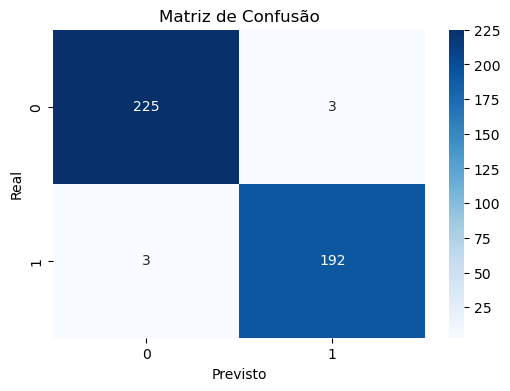

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [28]:
joblib.dump(pipeline, "modelo_obesidade.pkl")

['modelo_obesidade.pkl']